# Decision Tree Classification for Predicting CS-SINS scores of IgG1 and IgG4 antibodies

Author: Hsin-Ting Chen

Objective: The goal of this notebook is to use support vector regression to predict whether an IgG1 Fv region has high or low CS-SINS score.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [2]:
# identify relevent columns
Index=[
'patch_hyd',
'patch_hyd_1',
'patch_hyd_n',
'patch_hyd_%',
'patch_pos',
'patch_pos_1',
'patch_pos_n',
'patch_pos_%',
'patch_neg',
'patch_neg_1',
'patch_neg_n',
'patch_neg_%',
'patch_ion',
'patch_ion_1',
'patch_ion_n',
'patch_ion_%',
'patch_cdr_hyd',
'patch_cdr_hyd_1',
'patch_cdr_hyd_n',
'patch_cdr_pos',
'patch_cdr_pos_1',
'patch_cdr_pos_n',
'patch_cdr_neg',
'patch_cdr_neg_1',
'patch_cdr_neg_n',
'patch_cdr_ion',
'patch_cdr_ion_1',
'patch_cdr_ion_n',
'ens_dipole',
'pI_3D',
'asa_vdw',
'asa_hyd',
'asa_hph',
'app_charge','dipole_moment','hyd_moment',
'zdipole',
'zquadrupole',
'pI_seq',
]

In [3]:
# Add path to training and testing data here
X_train = pd.read_csv('train_x.csv').loc[:,Index]
y_train = pd.read_csv('train_y.csv')['CS-SINS Label']
X_test = pd.read_csv('test_x.csv').loc[:,Index]
y_test = pd.read_csv('test_y.csv')['CS-SINS Label']

Training Dataset Metrics
Accuracy: 0.88
Balanced Accuracy: 0.88
Precision: 0.87
Recall: 0.89
F1 Score: 0.88


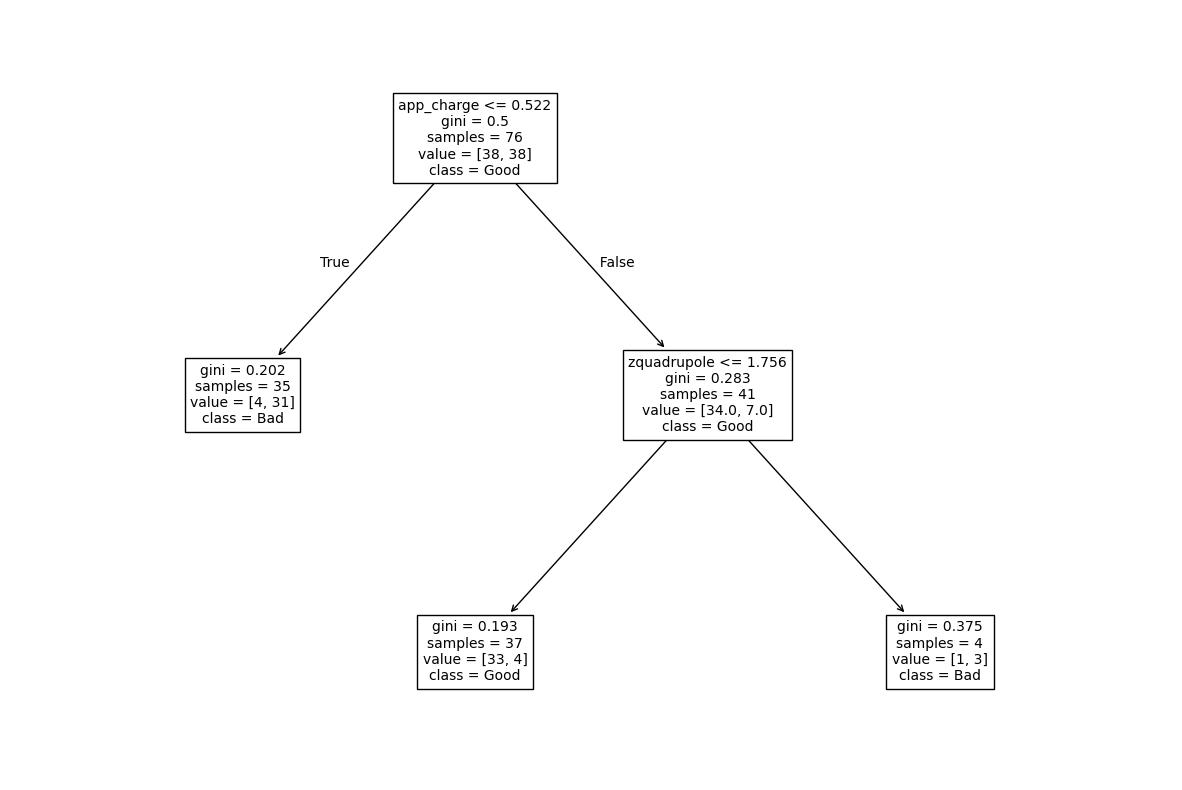

In [4]:
# train the model
clf = DecisionTreeClassifier(max_depth = 2, min_impurity_decrease=0.025,min_samples_leaf=4,random_state=1).fit(X_train, y_train)

# Evaluate the Training Dataset
ph6_predict = pd.DataFrame(clf.predict(X_train))
print("Training Dataset Metrics")
print("Accuracy:", f"{accuracy_score(ph6_predict, y_train):1.2f}")
print("Balanced Accuracy:", f"{balanced_accuracy_score(y_train,ph6_predict):1.2f}")
print("Precision:", f"{precision_score(y_train,ph6_predict.iloc[:,0],pos_label=1):1.2f}")
print("Recall:", f"{recall_score(y_train,ph6_predict.iloc[:,0],pos_label=1):1.2f}")
print("F1 Score:", f"{f1_score(y_train,ph6_predict.iloc[:,0],pos_label=1):1.2f}")

plt.figure(figsize = (15,10));
plot_tree(clf, feature_names = X_train.columns,class_names=["Good","Bad"], fontsize = 10);

In [5]:
# Evaluate the Testing Dataset
ph6_predict = pd.DataFrame(clf.predict(X_test))
print("Testing Dataset Metrics")
print("Accuracy:", f"{accuracy_score(ph6_predict, y_test):1.2f}")
print("Balanced Accuracy:", f"{balanced_accuracy_score(y_test,ph6_predict):1.2f}")
print("Precision:", f"{precision_score(y_test,ph6_predict.iloc[:,0],pos_label=1):1.2f}")
print("Recall:", f"{recall_score(y_test,ph6_predict.iloc[:,0],pos_label=1):1.2f}")
print("F1 Score:", f"{f1_score(y_test,ph6_predict.iloc[:,0],pos_label=1):1.2f}")

Testing Dataset Metrics
Accuracy: 0.79
Balanced Accuracy: 0.79
Precision: 0.73
Recall: 0.89
F1 Score: 0.80


In [6]:
# Evaluate the Entire Dataset
X = pd.concat([X_train, X_test])
y = pd.concat([y_train, y_test])
ph6_predict = pd.DataFrame(clf.predict(X))
print("Entire Dataset Metrics")
print("Accuracy:", f"{accuracy_score(ph6_predict, y):1.2f}")
print("Balanced Accuracy:", f"{balanced_accuracy_score(y,ph6_predict):1.2f}")
print("Precision:", f"{precision_score(y,ph6_predict.iloc[:,0],pos_label=1):1.2f}")
print("Recall:", f"{recall_score(y,ph6_predict.iloc[:,0],pos_label=1):1.2f}")
print("F1 Score:", f"{f1_score(y,ph6_predict.iloc[:,0],pos_label=1):1.2f}")

Entire Dataset Metrics
Accuracy: 0.86
Balanced Accuracy: 0.86
Precision: 0.84
Recall: 0.89
F1 Score: 0.87
